## Extract the ECM neighborhood for each cell

## Load csv

In [5]:
#Import Packages
import numpy as np
import seaborn as sns
import pandas as pd

from sklearn.cluster import MiniBatchKMeans
import matplotlib.pyplot as plt

In [31]:
cells = pd.read_csv('/hnscc_ecm_de.csv', index_col=0)

C:\Users\Guolan\.conda\envs\Scanpy_PAGA_01_22\lib\site-packages\numpy\lib\arraysetops.py:583: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  mask |= (ar1 == a)


## KNN

In [35]:
cols = ['CollagenI_count_norm','Fibronectin_count_norm','TenascinC_count_norm','Periostin_count_norm','CollagenIV_count_norm']

In [36]:
#Fill in based on above
n_neighborhoods = 4
neighborhood_name = "ecm25um"

km = MiniBatchKMeans(n_clusters = n_neighborhoods,random_state=0)

labels = km.fit_predict(cells[cols].values)

k_centroids = km.cluster_centers_
cells[neighborhood_name] = labels

niche_clusters = k_centroids

C:\Users\Guolan\.conda\envs\Scanpy_PAGA_01_22\lib\site-packages\sklearn\cluster\_kmeans.py:1046: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 12288 or by setting the environment variable OMP_NUM_THREADS=4
  warnings.warn(


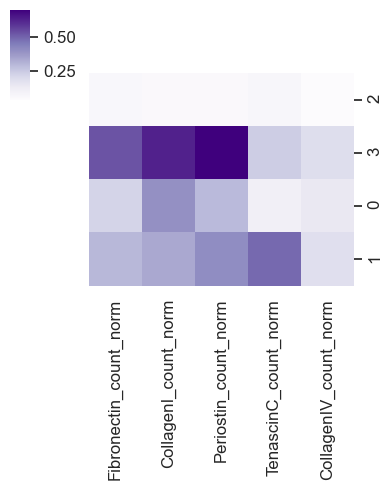

In [37]:
fc = niche_clusters
fc = pd.DataFrame(fc,columns = cols)
fc

sns.set(font_scale=1.1)
s=sns.clustermap(fc,cmap = 'Purples',figsize=(4,5))
s.ax_row_dendrogram.set_visible(False)
s.ax_col_dendrogram.set_visible(False)

#s.savefig("ecm_neighbor_hnscc_25um_4clusters.png",transparent=True, dpi=600, bbox_inches='tight')

## Defining ECM neighbor names

In [38]:
ecm25um_name = {'0': 'Collagen I-periostin',
           '1': 'TenascinC',
           '2': 'Low ECM',
           '3': 'Periostin-collagen I-fibronectin',
          } 

In [39]:
cells['ecm25um'] =  cells['ecm25um'].astype(str)

cells['ecm25um_name'] = cells['ecm25um'].map(ecm25um_name)

In [40]:
my_order = ['1','0','3','2']

df_cnt = cells.groupby(['ecm25um'])['cell_id'].count()
df_cnt = df_cnt.reindex(my_order)

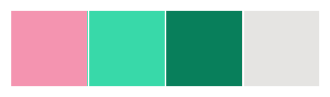

In [41]:
my_color = ['#f494b0','#38d9a9','#087f5b','#E5E4E2']
sns.palplot(my_color)

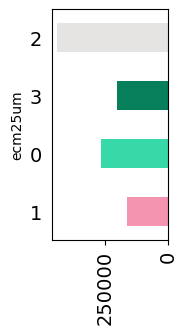

In [43]:
bars = df_cnt.plot.barh(figsize=(1.5,3), 
                 color=my_color)
plt.style.use('default')

plt.xticks(fontsize=14,rotation=90)
plt.yticks(fontsize=14)
ax = plt.gca()
ax.grid(False)
ax.spines['top'].set_visible(True)
ax.spines['right'].set_visible(True)
ax.spines['bottom'].set_visible(True)
ax.spines['left'].set_visible(True)
ax.tick_params(left = False,bottom = True)

plt.gca().invert_xaxis()
    
#plt.savefig('ecmn_barplot_flipped_nonum.png',transparent=True, dpi=600, bbox_inches='tight')